# Ethnicity Metrics
Comparison of perceived ethnicity in the **ground-truth** reference rankings vs. the **LLM recommendations**.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

ETHNICITY_DIR  = "../../results/ethnicity/"
LOOKUP_PATH    = ETHNICITY_DIR + "researcher_ethnicity_lookup.csv"
REC_ETH_PATH   = "../../results/summary/recommendations_with_ethnicity.csv"

ETH_ORDER  = ["White", "Asian", "Hispanic or Latino", "Black or African American", "Unknown"]
ETH_COLORS = ["#4878CF", "#6ACC65", "#D65F5F", "#B47CC7", "#aaaaaa"]
COLOR_MAP  = dict(zip(ETH_ORDER, ETH_COLORS))

FIELD_FILES = {
    "Biology":          ETHNICITY_DIR + "DataFrameRankings_Genderize_Namsor_Biology_with_ethnicity.csv",
    "Computer Science": ETHNICITY_DIR + "DataFrameRankings_Genderize_Namsor_Computer_Science_with_ethnicity.csv",
    "Mathematics":      ETHNICITY_DIR + "DataFrameRankings_Genderize_Namsor_Mathematics_with_ethnicity.csv",
    "Physics":          ETHNICITY_DIR + "DataFrameRankings_Genderize_Namsor_Physics_with_ethnicity.csv",
    "Psychology":       ETHNICITY_DIR + "DataFrameRankings_Genderize_Namsor_Psychology_with_ethnicity.csv",
    "Sociology":        ETHNICITY_DIR + "DataFrameRankings_Genderize_Namsor_Sociology_with_ethnicity.csv",
}

FIELD_MAP = {
    "Biología": "Biology",        "Biologie": "Biology",
    "Ciencias de la computación": "Computer Science", "Informatik": "Computer Science",
    "Matemáticas": "Mathematics",  "Mathematik": "Mathematics",
    "Física": "Physics",           "Physik": "Physics",
    "Psicología": "Psychology",    "Psychologie": "Psychology",
    "Sociología": "Sociology",     "Soziologie": "Sociology",
}

VALID_FLAGS = {"cleaned", "unchanged", "fixed_dict"}

---
## 1. Ground Truth — Reference Rankings
Source: `researcher_ethnicity_lookup.csv` (unique researchers across all fields).

In [2]:
lookup = pd.read_csv(LOOKUP_PATH)
print(f"Unique researchers (lookup): {len(lookup):,}")
print()

gt_overall = lookup["perceived_ethnicity"].value_counts()
gt_overall = gt_overall.reindex([e for e in ETH_ORDER if e in gt_overall.index])
gt_pct = (gt_overall / gt_overall.sum() * 100).round(2)

gt_table = pd.DataFrame({"count": gt_overall, "pct": gt_pct})
gt_table.index.name = "perceived_ethnicity"
print("Ground-truth ethnicity distribution (unique researchers):")
print(gt_table.to_string())

Unique researchers (lookup): 6,686,108

Ground-truth ethnicity distribution (unique researchers):
                             count    pct
perceived_ethnicity                      
White                      2566474  38.39
Asian                      2500222  37.39
Hispanic or Latino         1105999  16.54
Black or African American   501953   7.51
Unknown                      11460   0.17


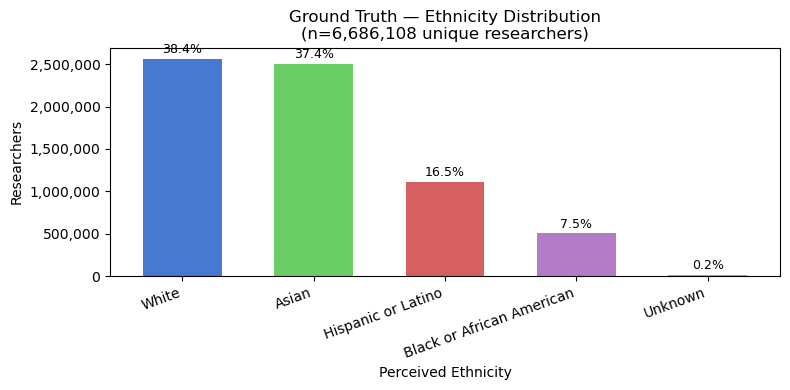

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = [COLOR_MAP.get(e, "#cccccc") for e in gt_overall.index]
gt_overall.plot(kind="bar", ax=ax, color=colors, width=0.6)
ax.set_title(f"Ground Truth — Ethnicity Distribution\n(n={gt_overall.sum():,} unique researchers)")
ax.set_xlabel("Perceived Ethnicity")
ax.set_ylabel("Researchers")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar, pct in zip(ax.patches, gt_pct):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + gt_overall.sum()*0.005,
            f"{pct:.1f}%", ha="center", va="bottom", fontsize=9)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [4]:
# Loads each field file (can take 1-2 min per file — reads ~140M rows total)
field_eth_gt = {}
for field, fpath in FIELD_FILES.items():
    df = pd.read_csv(fpath, usecols=["Researcher_id", "perceived_ethnicity"],
                     dtype={"perceived_ethnicity": "category"})
    df = df.drop_duplicates("Researcher_id")
    field_eth_gt[field] = df["perceived_ethnicity"].value_counts()
    print(f"  {field}: {len(df):,} unique researchers")

gt_field_df = pd.DataFrame(field_eth_gt).T.fillna(0).astype(int)
gt_field_df = gt_field_df[[c for c in ETH_ORDER if c in gt_field_df.columns]]
print()
print(gt_field_df.to_string())

  Biology: 2,677,566 unique researchers
  Computer Science: 1,974,305 unique researchers
  Mathematics: 805,926 unique researchers
  Physics: 1,415,108 unique researchers
  Psychology: 1,236,641 unique researchers
  Sociology: 635,359 unique researchers

perceived_ethnicity   White    Asian  Hispanic or Latino  Black or African American  Unknown
Biology              978598  1036553              460928                     197132     4355
Computer Science     752142   847246              243905                     127839     3173
Mathematics          302987   344974              106937                      49661     1367
Physics              556079   533659              247982                      75148     2240
Psychology           529103   390800              189801                     124489     2448
Sociology            276876   138880              145356                      72778     1469


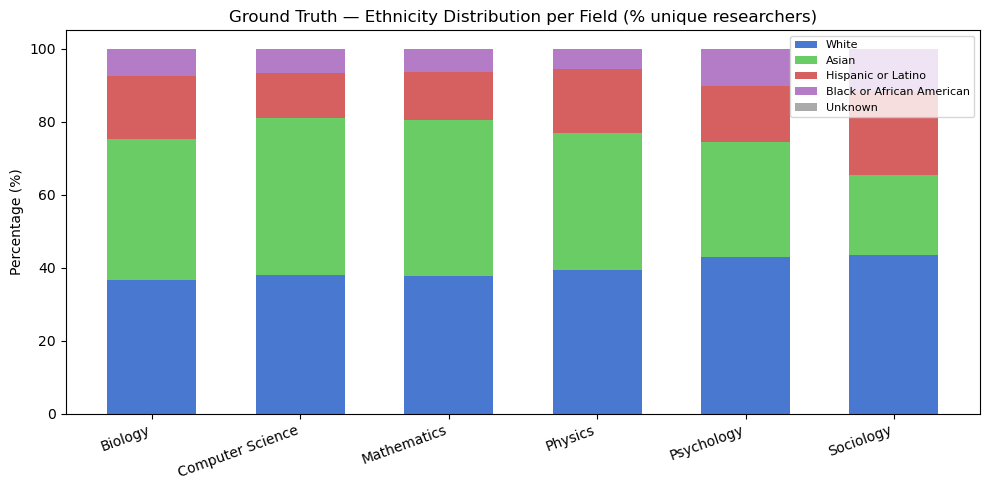

In [5]:
gt_field_pct = gt_field_df.div(gt_field_df.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5))
bottom = np.zeros(len(gt_field_pct))
for eth in gt_field_pct.columns:
    vals = gt_field_pct[eth].values
    bars = ax.bar(gt_field_pct.index, vals, bottom=bottom,
                  color=COLOR_MAP.get(eth, "#ccc"), label=eth, width=0.6)
    bottom += vals
ax.set_title("Ground Truth — Ethnicity Distribution per Field (% unique researchers)")
ax.set_ylabel("Percentage (%)")
ax.set_ylim(0, 105)
ax.legend(loc="upper right", fontsize=8)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

---
## 2. LLM Recommendations
Source: `recommendations_with_ethnicity.csv`.
Only valid responses (`cleaned`, `unchanged`, `fixed_dict`) are included.
Rows with `Unknown` ethnicity are kept but shown separately.

In [6]:
rdf = pd.read_csv(REC_ETH_PATH, low_memory=False)

# Keep only valid recommendations
rdf_valid = rdf[rdf["valid_flag"].isin(VALID_FLAGS)].copy()

# Normalize field names to English
rdf_valid["field_en"] = rdf_valid["field"].map(FIELD_MAP).fillna(rdf_valid["field"])

total_valid = len(rdf_valid)
print(f"Total valid recommendations:  {total_valid:,}")
print(f"Models:                       {rdf_valid['model'].nunique()}")
print(f"Fields:                       {sorted(rdf_valid['field_en'].unique())}")
print()

rec_overall = rdf_valid["perceived_ethnicity"].value_counts()
rec_overall = rec_overall.reindex([e for e in ETH_ORDER if e in rec_overall.index])
rec_pct = (rec_overall / rec_overall.sum() * 100).round(2)

rec_table = pd.DataFrame({"count": rec_overall, "pct": rec_pct})
rec_table.index.name = "perceived_ethnicity"
print("Recommendations ethnicity distribution (valid only):")
print(rec_table.to_string())

Total valid recommendations:  825,192
Models:                       43
Fields:                       ['Biology', 'Computer Science', 'Mathematics', 'Physics', 'Psychology', 'Sociology']

Recommendations ethnicity distribution (valid only):
                            count    pct
perceived_ethnicity                     
White                      179213  21.72
Asian                      200865  24.34
Hispanic or Latino         101675  12.32
Black or African American   88330  10.70
Unknown                    255109  30.92


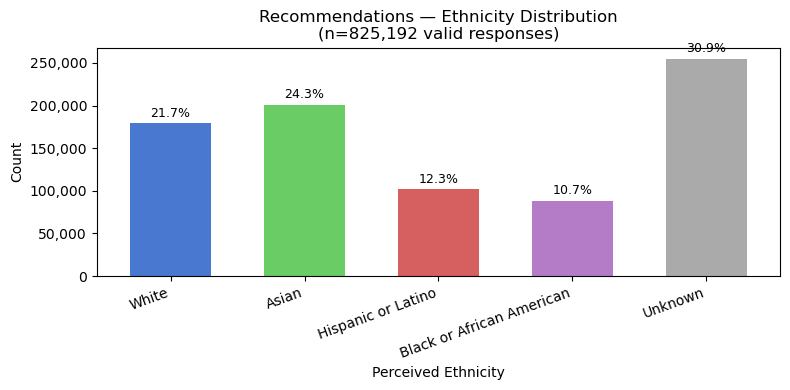

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = [COLOR_MAP.get(e, "#cccccc") for e in rec_overall.index]
rec_overall.plot(kind="bar", ax=ax, color=colors, width=0.6)
ax.set_title(f"Recommendations — Ethnicity Distribution\n(n={total_valid:,} valid responses)")
ax.set_xlabel("Perceived Ethnicity")
ax.set_ylabel("Count")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar, pct in zip(ax.patches, rec_pct):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total_valid*0.005,
            f"{pct:.1f}%", ha="center", va="bottom", fontsize=9)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

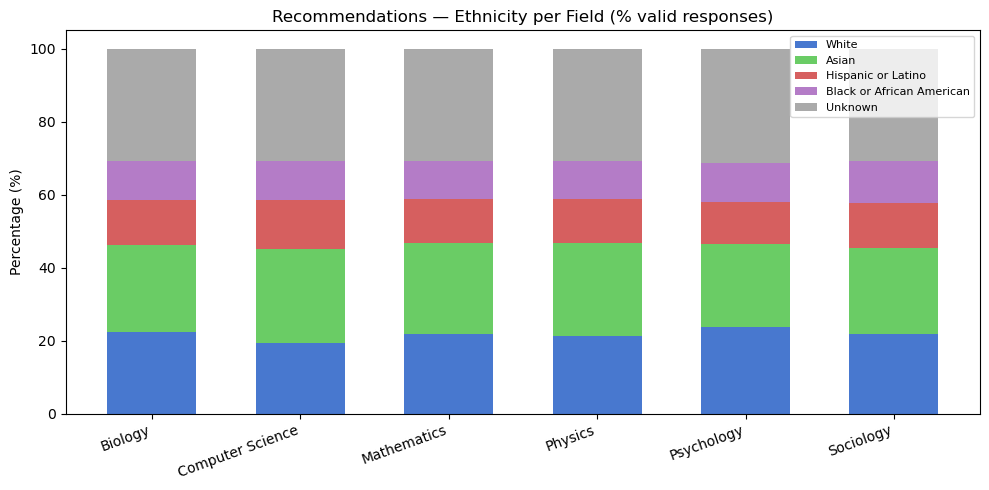

In [8]:
rec_field = (
    rdf_valid.groupby(["field_en", "perceived_ethnicity"])
    .size().unstack(fill_value=0)
)
rec_field = rec_field[[c for c in ETH_ORDER if c in rec_field.columns]]
rec_field_pct = rec_field.div(rec_field.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5))
bottom = np.zeros(len(rec_field_pct))
for eth in rec_field_pct.columns:
    vals = rec_field_pct[eth].values
    ax.bar(rec_field_pct.index, vals, bottom=bottom,
           color=COLOR_MAP.get(eth, "#ccc"), label=eth, width=0.6)
    bottom += vals
ax.set_title("Recommendations — Ethnicity per Field (% valid responses)")
ax.set_ylabel("Percentage (%)")
ax.set_ylim(0, 105)
ax.legend(loc="upper right", fontsize=8)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

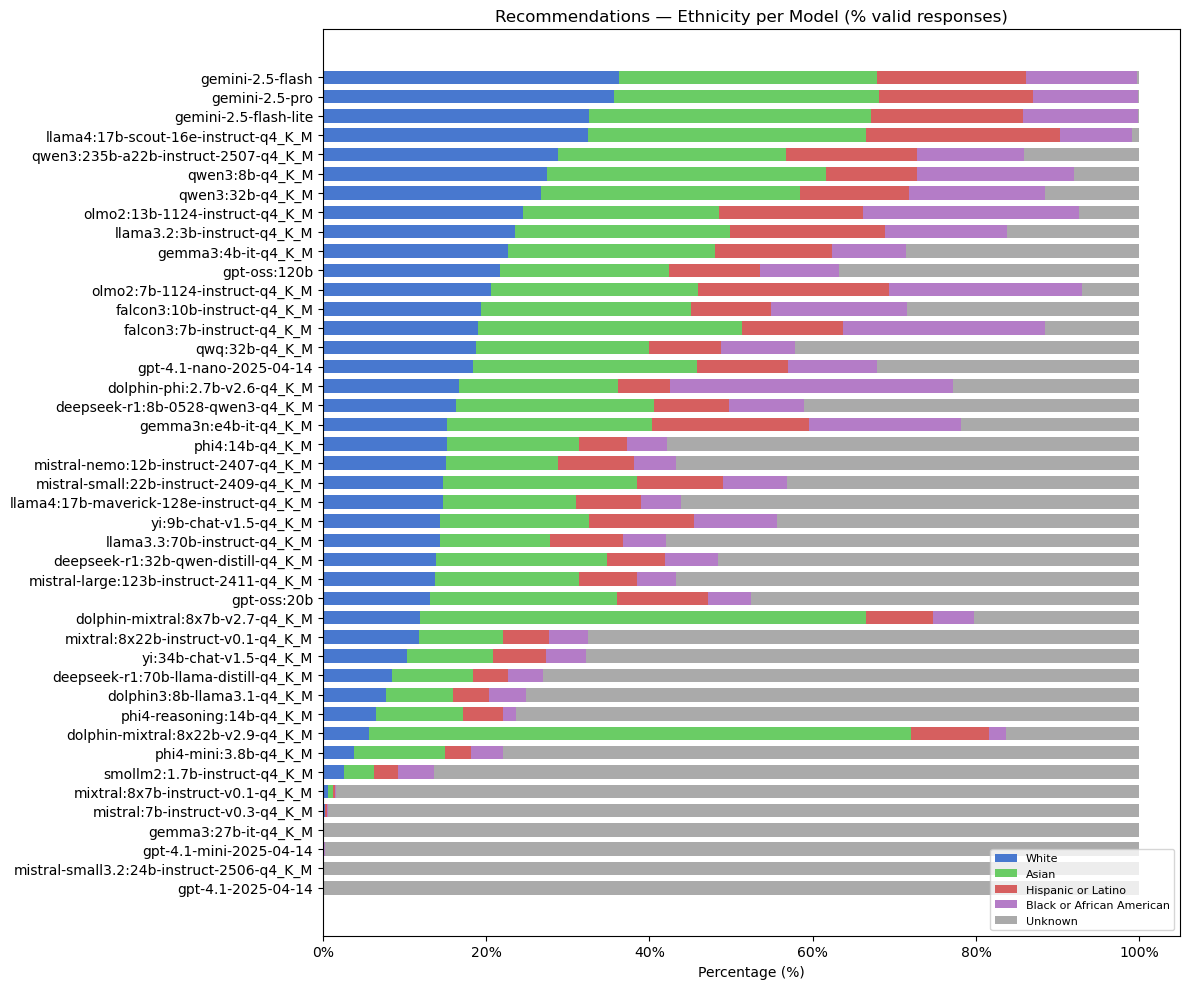

In [9]:
rec_model = (
    rdf_valid.groupby(["model", "perceived_ethnicity"])
    .size().unstack(fill_value=0)
)
rec_model = rec_model[[c for c in ETH_ORDER if c in rec_model.columns]]
rec_model_pct = rec_model.div(rec_model.sum(axis=1), axis=0) * 100
# Sort by White desc for readability
rec_model_pct = rec_model_pct.sort_values("White", ascending=True)

fig, ax = plt.subplots(figsize=(12, 10))
left = np.zeros(len(rec_model_pct))
for eth in rec_model_pct.columns:
    vals = rec_model_pct[eth].values
    ax.barh(rec_model_pct.index, vals, left=left,
            color=COLOR_MAP.get(eth, "#ccc"), label=eth, height=0.7)
    left += vals
ax.set_title("Recommendations — Ethnicity per Model (% valid responses)")
ax.set_xlabel("Percentage (%)")
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

---
## 3. Ground Truth vs. Recommendations — Side-by-side
`Unknown` excluded from comparison to focus on identifiable ethnicity.

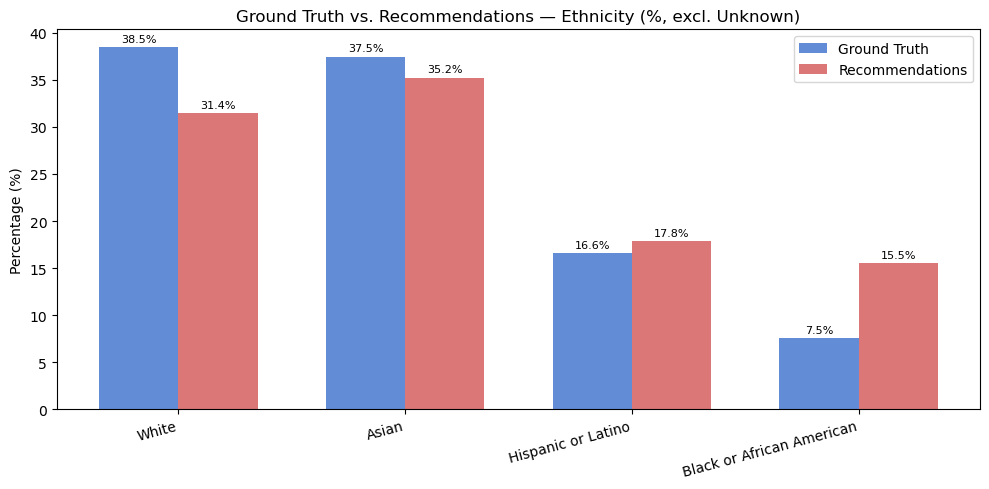

                           GT (%)  Rec (%)  Delta (pp)
perceived_ethnicity                                   
White                       38.45    31.44       -7.01
Asian                       37.46    35.23       -2.22
Hispanic or Latino          16.57    17.84        1.26
Black or African American    7.52    15.49        7.97


In [10]:
KNOWN_ETH = [e for e in ETH_ORDER if e != "Unknown"]

gt_known  = gt_overall.reindex(KNOWN_ETH).fillna(0)
rec_known = rec_overall.reindex(KNOWN_ETH).fillna(0)

gt_known_pct  = gt_known  / gt_known.sum()  * 100
rec_known_pct = rec_known / rec_known.sum() * 100

x = np.arange(len(KNOWN_ETH))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars_gt  = ax.bar(x - w/2, gt_known_pct.values,  w, label="Ground Truth",    color="#4878CF", alpha=0.85)
bars_rec = ax.bar(x + w/2, rec_known_pct.values, w, label="Recommendations", color="#D65F5F", alpha=0.85)

for bar in bars_gt:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=8)
for bar in bars_rec:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=8)

ax.set_title("Ground Truth vs. Recommendations — Ethnicity (%, excl. Unknown)")
ax.set_ylabel("Percentage (%)")
ax.set_xticks(x)
ax.set_xticklabels(KNOWN_ETH, rotation=15, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

# Numeric delta table
delta = (rec_known_pct - gt_known_pct).round(2)
compare_df = pd.DataFrame({
    "GT (%)": gt_known_pct.round(2),
    "Rec (%)": rec_known_pct.round(2),
    "Delta (pp)": delta,
})
compare_df.index.name = "perceived_ethnicity"
print(compare_df.to_string())

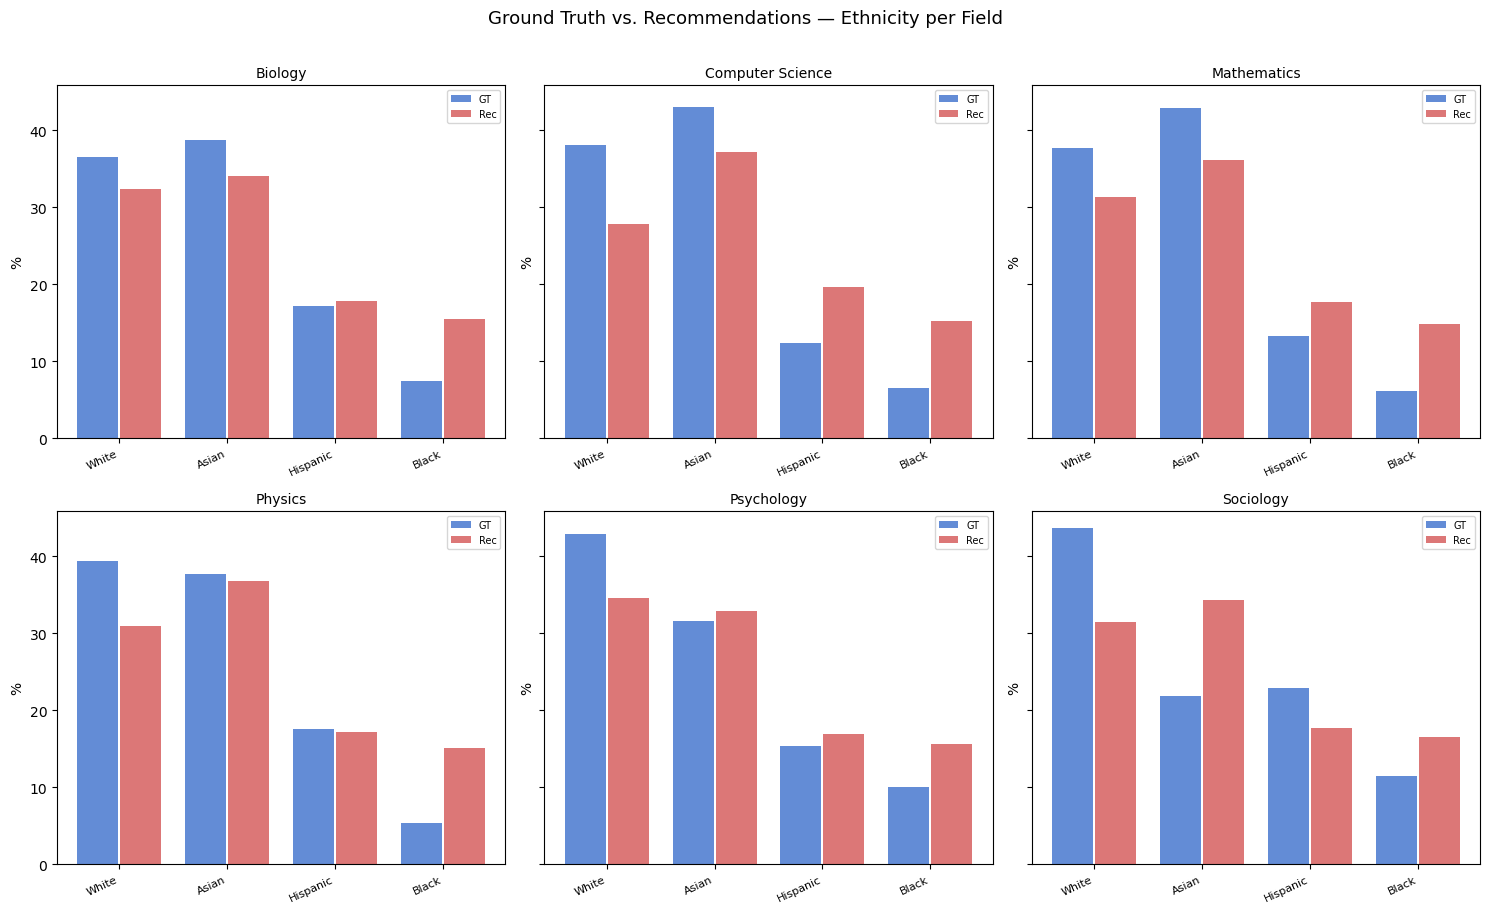

In [11]:
# Per-field comparison: GT vs Rec (requires field_eth_gt from Section 1)
fields = sorted(FIELD_FILES.keys())
fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharey=True)
axes = axes.flatten()

for ax, field in zip(axes, fields):
    gt_f  = gt_field_df.loc[field, KNOWN_ETH] if field in gt_field_df.index else pd.Series(dtype=float)
    rec_f = rec_field.loc[field, KNOWN_ETH]   if field in rec_field.index   else pd.Series(dtype=float)

    gt_f_pct  = (gt_f  / gt_f.sum()  * 100).fillna(0)
    rec_f_pct = (rec_f / rec_f.sum() * 100).fillna(0)

    x = np.arange(len(KNOWN_ETH))
    ax.bar(x - 0.2, gt_f_pct.values,  0.38, label="GT",  color="#4878CF", alpha=0.85)
    ax.bar(x + 0.2, rec_f_pct.values, 0.38, label="Rec", color="#D65F5F", alpha=0.85)
    ax.set_title(field, fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels([e.split()[0] for e in KNOWN_ETH], rotation=25, ha="right", fontsize=8)
    ax.set_ylabel("%")
    ax.legend(fontsize=7)

fig.suptitle("Ground Truth vs. Recommendations — Ethnicity per Field", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()